# Formative 2: Hidden Markov Model for Human Activity Recognition

This notebook implements a complete HMM pipeline for the four required activities: `standing`, `walking`, `jump`, and `still`.

## 1. Imports and Configuration

In [1]:
from pathlib import Path
import re
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score

np.set_printoptions(precision=4, suppress=True)
sns.set_theme(style='whitegrid')

DATASET_DIR = Path('dataset')
TARGET_FS = 50.0  # harmonized rate in Hz (20 ms)
WINDOW_SEC = 2.0
OVERLAP = 0.5
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

ACTIVITIES = ['standing', 'walking', 'jump', 'still']
ACT_TO_ID = {a: i for i, a in enumerate(ACTIVITIES)}
ID_TO_ACT = {i: a for a, i in ACT_TO_ID.items()}

## 2. Dataset Discovery and Utility Functions

In [2]:
def infer_activity(filename: str) -> str:
    name = filename.lower()
    if name.startswith('standing'):
        return 'standing'
    if name.startswith('walking'):
        return 'walking'
    if name.startswith('jump'):
        return 'jump'
    if name.startswith('still'):
        return 'still'
    raise ValueError(f'Cannot infer activity from {filename}')

def list_zip_files(dataset_dir: Path):
    zips = sorted(dataset_dir.glob('*.zip'))
    records = []
    for p in zips:
        activity = infer_activity(p.name)
        records.append({'path': p, 'activity': activity})
    return pd.DataFrame(records)

files_df = list_zip_files(DATASET_DIR)
display(files_df['activity'].value_counts().rename('file_count'))
display(files_df.head())

activity
still       13
walking     13
jump        12
standing    12
Name: file_count, dtype: int64

,path,activity
0,dataset/jump_eight-2026-03-07_20-26-31.zip,jump
1,dataset/jump_eleven-2026-03-07_20-30-35.zip,jump
2,dataset/jump_five-2026-03-07_20-26-02.zip,jump
3,dataset/jump_four-2026-03-07_20-25-50.zip,jump
4,dataset/jump_nine-2026-03-07_20-27-13.zip,jump


In [3]:
def read_sensor_from_zip(zip_path: Path, inner_csv: str) -> pd.DataFrame:
    with zipfile.ZipFile(zip_path, 'r') as zf:
        with zf.open(inner_csv) as f:
            df = pd.read_csv(f)
    required = ['time', 'x', 'y', 'z']
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f'{zip_path.name}:{inner_csv} missing columns {missing}')
    df = df[['time', 'x', 'y', 'z']].copy()
    df = df.sort_values('time').dropna().reset_index(drop=True)
    return df

def estimate_fs(df: pd.DataFrame) -> float:
    t = df['time'].to_numpy(np.int64)
    dt = np.diff(t) / 1e9
    dt = dt[dt > 0]
    if len(dt) == 0:
        return np.nan
    return float(1.0 / np.median(dt))

def resample_xyz(df: pd.DataFrame, target_fs: float, end_time_s: float | None = None) -> pd.DataFrame:
    t_ns = df['time'].to_numpy(np.int64)
    t = (t_ns - t_ns[0]) / 1e9
    if end_time_s is None:
        end_time_s = float(t[-1])
    if end_time_s <= 0:
        raise ValueError('Non-positive duration in sequence')

    t_new = np.arange(0, end_time_s, 1.0 / target_fs)
    out = pd.DataFrame({'t': t_new})
    for axis in ['x', 'y', 'z']:
        out[axis] = np.interp(t_new, t, df[axis].to_numpy(float))
    return out

def load_and_harmonize(zip_path: Path, target_fs: float = TARGET_FS) -> tuple[pd.DataFrame, float, float]:
    acc = read_sensor_from_zip(zip_path, 'Accelerometer.csv')
    gyr = read_sensor_from_zip(zip_path, 'Gyroscope.csv')

    fs_acc = estimate_fs(acc)
    fs_gyr = estimate_fs(gyr)

    acc_t = (acc['time'].to_numpy(np.int64) - int(acc['time'].iloc[0])) / 1e9
    gyr_t = (gyr['time'].to_numpy(np.int64) - int(gyr['time'].iloc[0])) / 1e9
    end_t = min(float(acc_t[-1]), float(gyr_t[-1]))

    acc_r = resample_xyz(acc, target_fs=target_fs, end_time_s=end_t)
    gyr_r = resample_xyz(gyr, target_fs=target_fs, end_time_s=end_t)

    merged = pd.DataFrame({
        't': acc_r['t'],
        'ax': acc_r['x'],
        'ay': acc_r['y'],
        'az': acc_r['z'],
        'gx': gyr_r['x'],
        'gy': gyr_r['y'],
        'gz': gyr_r['z'],
    })
    return merged, fs_acc, fs_gyr

def dominant_frequency_and_energy(x: np.ndarray, fs: float) -> tuple[float, float]:
    x = np.asarray(x, dtype=float)
    x = x - np.mean(x)
    n = len(x)
    if n < 4:
        return 0.0, 0.0
    fft_vals = np.fft.rfft(x)
    power = (np.abs(fft_vals) ** 2) / max(n, 1)
    freqs = np.fft.rfftfreq(n, d=1.0 / fs)

    if len(power) <= 1:
        return 0.0, float(np.sum(power))

    idx = int(np.argmax(power[1:]) + 1)
    dom_f = float(freqs[idx])
    energy = float(np.sum(power))
    return dom_f, energy

def extract_window_features(win_df: pd.DataFrame, fs: float) -> dict:
    ax, ay, az = [win_df[c].to_numpy(float) for c in ['ax', 'ay', 'az']]
    gx, gy, gz = [win_df[c].to_numpy(float) for c in ['gx', 'gy', 'gz']]

    amag = np.sqrt(ax**2 + ay**2 + az**2)
    gmag = np.sqrt(gx**2 + gy**2 + gz**2)

    acc_dom_f, acc_energy = dominant_frequency_and_energy(amag, fs)
    gyr_dom_f, gyr_energy = dominant_frequency_and_energy(gmag, fs)

    eps = 1e-8
    feats = {
        'acc_mean': float(np.mean(amag)),
        'acc_std': float(np.std(amag)),
        'acc_var': float(np.var(amag)),
        'acc_sma': float(np.mean(np.abs(ax) + np.abs(ay) + np.abs(az))),
        'gyr_mean': float(np.mean(gmag)),
        'gyr_std': float(np.std(gmag)),
        'gyr_var': float(np.var(gmag)),
        'gyr_sma': float(np.mean(np.abs(gx) + np.abs(gy) + np.abs(gz))),
        'corr_acc_xy': float(np.corrcoef(ax, ay)[0, 1] if np.std(ax) > eps and np.std(ay) > eps else 0.0),
        'corr_acc_xz': float(np.corrcoef(ax, az)[0, 1] if np.std(ax) > eps and np.std(az) > eps else 0.0),
        'corr_acc_yz': float(np.corrcoef(ay, az)[0, 1] if np.std(ay) > eps and np.std(az) > eps else 0.0),
        'acc_dom_freq': acc_dom_f,
        'acc_spec_energy': acc_energy,
        'gyr_dom_freq': gyr_dom_f,
        'gyr_spec_energy': gyr_energy,
    }
    return feats

## 3. Build Windowed Sequences and Split Unseen Test Files

In [4]:
def make_windows(df: pd.DataFrame, fs: float, window_sec: float, overlap: float) -> list[pd.DataFrame]:
    win_n = int(window_sec * fs)
    step = int(win_n * (1.0 - overlap))
    if step < 1:
        step = 1

    windows = []
    for start in range(0, len(df) - win_n + 1, step):
        windows.append(df.iloc[start:start + win_n].reset_index(drop=True))
    return windows

sequence_rows = []
sampling_rows = []

for _, row in files_df.iterrows():
    zip_path = row['path']
    activity = row['activity']

    merged, fs_acc, fs_gyr = load_and_harmonize(zip_path, target_fs=TARGET_FS)
    windows = make_windows(merged, TARGET_FS, WINDOW_SEC, OVERLAP)

    X = []
    for w in windows:
        X.append(extract_window_features(w, TARGET_FS))

    if len(X) == 0:
        continue

    X_df = pd.DataFrame(X)
    y = np.full(len(X_df), ACT_TO_ID[activity], dtype=int)

    sequence_rows.append({
        'file': zip_path.name,
        'activity': activity,
        'X': X_df,
        'y': y
    })

    sampling_rows.append({
        'file': zip_path.name,
        'activity': activity,
        'acc_fs_raw': fs_acc,
        'gyr_fs_raw': fs_gyr,
        'fs_harmonized': TARGET_FS,
        'duration_s': float(merged['t'].iloc[-1])
    })

seq_df = pd.DataFrame(sequence_rows)
sampling_df = pd.DataFrame(sampling_rows)

print('Total usable files:', len(seq_df))
display(seq_df.groupby('activity')['file'].count().rename('usable_files'))
display(sampling_df.head())

Total usable files: 50


activity
jump        12
standing    12
still       13
walking     13
Name: usable_files, dtype: int64

,file,activity,acc_fs_raw,gyr_fs_raw,fs_harmonized,duration_s
0,jump_eight-2026-03-07_20-26-31.zip,jump,99.670092,99.670092,50.0,7.60
1,jump_eleven-2026-03-07_20-30-35.zip,jump,99.670092,99.670092,50.0,8.04
2,jump_five-2026-03-07_20-26-02.zip,jump,99.669099,99.669099,50.0,5.96
3,jump_four-2026-03-07_20-25-50.zip,jump,99.669099,99.669099,50.0,9.08
4,jump_nine-2026-03-07_20-27-13.zip,jump,99.671085,99.671085,50.0,8.40


In [5]:
# Keep at least 2 unseen files overall; here we hold out 2 files per activity where possible.
train_idx = []
test_idx = []

for act in ACTIVITIES:
    idx = seq_df.index[seq_df['activity'] == act].tolist()
    idx = sorted(idx)
    n_test = 2 if len(idx) >= 4 else 1
    test_idx.extend(idx[-n_test:])
    train_idx.extend(idx[:-n_test])

train_df = seq_df.loc[sorted(train_idx)].reset_index(drop=True)
test_df = seq_df.loc[sorted(test_idx)].reset_index(drop=True)

print('Train files:', len(train_df), 'Test files:', len(test_df))
display(train_df.groupby('activity')['file'].count().rename('train_files'))
display(test_df.groupby('activity')['file'].count().rename('test_files'))

Train files: 42 Test files: 8


activity
jump        10
standing    10
still       11
walking     11
Name: train_files, dtype: int64

activity
jump        2
standing    2
still       2
walking     2
Name: test_files, dtype: int64

## 4. Normalize Features (Z-score on Train Only)

In [6]:
feature_cols = train_df.iloc[0]['X'].columns.tolist()

X_train_all = np.vstack([r['X'][feature_cols].to_numpy(float) for _, r in train_df.iterrows()])
scaler = StandardScaler()
scaler.fit(X_train_all)

def transform_sequences(df: pd.DataFrame):
    X_list, y_list, lengths, files = [], [], [], []
    for _, r in df.iterrows():
        X_raw = r['X'][feature_cols].to_numpy(float)
        X_scaled = scaler.transform(X_raw)
        y = r['y']
        X_list.append(X_scaled)
        y_list.append(y)
        lengths.append(len(X_scaled))
        files.append(r['file'])
    return X_list, y_list, lengths, files

X_train_seq, y_train_seq, train_lengths, train_files = transform_sequences(train_df)
X_test_seq, y_test_seq, test_lengths, test_files = transform_sequences(test_df)

print('Feature count:', len(feature_cols))
print('Total training windows:', sum(train_lengths))
print('Total test windows:', sum(test_lengths))

Feature count: 15
Total training windows: 323
Total test windows: 61


## 5. HMM (Baum-Welch + Viterbi) From Scratch

In [7]:
def logsumexp(a, axis=None, keepdims=False):
    a = np.asarray(a)
    a_max = np.max(a, axis=axis, keepdims=True)
    summ = np.sum(np.exp(a - a_max), axis=axis, keepdims=True)
    out = a_max + np.log(np.maximum(summ, 1e-300))
    if not keepdims and axis is not None:
        out = np.squeeze(out, axis=axis)
    return out

class GaussianHMM:
    def __init__(self, n_states: int, n_features: int, random_state: int = 42):
        self.n_states = n_states
        self.n_features = n_features
        self.rng = np.random.default_rng(random_state)

        self.pi = np.full(n_states, 1.0 / n_states)
        self.A = np.full((n_states, n_states), 1.0 / n_states)
        self.means = self.rng.normal(0, 1, (n_states, n_features))
        self.vars = np.ones((n_states, n_features))

    def _log_emission(self, X):
        X = np.asarray(X, dtype=float)
        diff = X[:, None, :] - self.means[None, :, :]
        log_det = np.sum(np.log(2.0 * np.pi * self.vars), axis=1)
        quad = np.sum((diff ** 2) / self.vars[None, :, :], axis=2)
        return -0.5 * (log_det[None, :] + quad)

    def _forward(self, logB):
        T = logB.shape[0]
        logA = np.log(np.maximum(self.A, 1e-300))
        logpi = np.log(np.maximum(self.pi, 1e-300))

        alpha = np.zeros((T, self.n_states))
        c = np.zeros(T)

        alpha[0] = logpi + logB[0]
        c[0] = logsumexp(alpha[0], axis=0)
        alpha[0] -= c[0]

        for t in range(1, T):
            alpha[t] = logB[t] + logsumexp(alpha[t - 1][:, None] + logA, axis=0)
            c[t] = logsumexp(alpha[t], axis=0)
            alpha[t] -= c[t]

        loglik = float(np.sum(c))
        return alpha, c, loglik

    def _backward(self, logB, c):
        T = logB.shape[0]
        logA = np.log(np.maximum(self.A, 1e-300))

        beta = np.zeros((T, self.n_states))
        beta[T - 1] = 0.0

        for t in range(T - 2, -1, -1):
            beta[t] = logsumexp(logA + logB[t + 1][None, :] + beta[t + 1][None, :], axis=1)
            beta[t] -= c[t + 1]

        return beta

    def initialize_from_labeled(self, X_seqs, y_seqs):
        n = self.n_states
        d = self.n_features
        eps = 1e-3

        pi = np.ones(n) * eps
        A = np.ones((n, n)) * eps

        all_X = np.vstack(X_seqs)
        global_var = np.var(all_X, axis=0) + eps

        means = np.zeros((n, d))
        vars_ = np.zeros((n, d))

        for X, y in zip(X_seqs, y_seqs):
            pi[y[0]] += 1
            for t in range(len(y) - 1):
                A[y[t], y[t + 1]] += 1

        for s in range(n):
            chunks = []
            for X, y in zip(X_seqs, y_seqs):
                mask = (y == s)
                if np.any(mask):
                    chunks.append(X[mask])
            if len(chunks) == 0:
                means[s] = np.mean(all_X, axis=0) + self.rng.normal(0, 0.1, d)
                vars_[s] = global_var.copy()
            else:
                Z = np.vstack(chunks)
                means[s] = np.mean(Z, axis=0)
                vars_[s] = np.var(Z, axis=0) + eps

        self.pi = pi / np.sum(pi)
        self.A = A / np.sum(A, axis=1, keepdims=True)
        self.means = means
        self.vars = np.maximum(vars_, eps)

    def baum_welch(self, X_seqs, max_iter=100, tol=1e-4, min_var=1e-3, verbose=True):
        prev_loglik = None
        history = []

        for it in range(max_iter):
            pi_acc = np.zeros(self.n_states)
            A_num = np.zeros((self.n_states, self.n_states))
            A_den = np.zeros(self.n_states)
            mean_num = np.zeros((self.n_states, self.n_features))
            var_num = np.zeros((self.n_states, self.n_features))
            gamma_sum = np.zeros(self.n_states)

            total_loglik = 0.0

            for X in X_seqs:
                logB = self._log_emission(X)
                alpha, c, ll = self._forward(logB)
                beta = self._backward(logB, c)
                total_loglik += ll

                log_gamma = alpha + beta
                log_gamma -= logsumexp(log_gamma, axis=1, keepdims=True)
                gamma = np.exp(log_gamma)

                pi_acc += gamma[0]

                T = X.shape[0]
                logA = np.log(np.maximum(self.A, 1e-300))
                for t in range(T - 1):
                    log_xi = (
                        alpha[t][:, None]
                        + logA
                        + logB[t + 1][None, :]
                        + beta[t + 1][None, :]
                    )
                    log_xi -= logsumexp(log_xi)
                    xi = np.exp(log_xi)
                    A_num += xi
                    A_den += gamma[t]

                gamma_sum += np.sum(gamma, axis=0)
                mean_num += gamma.T @ X

                for s in range(self.n_states):
                    diff = X - self.means[s]
                    var_num[s] += np.sum(gamma[:, s][:, None] * (diff ** 2), axis=0)

            self.pi = pi_acc / np.sum(pi_acc)
            self.A = A_num / np.maximum(A_den[:, None], 1e-300)
            self.A = self.A / np.maximum(np.sum(self.A, axis=1, keepdims=True), 1e-300)

            self.means = mean_num / np.maximum(gamma_sum[:, None], 1e-300)
            self.vars = var_num / np.maximum(gamma_sum[:, None], 1e-300)
            self.vars = np.maximum(self.vars, min_var)

            history.append(total_loglik)
            if verbose and (it == 0 or (it + 1) % 5 == 0):
                print(f'Iter {it + 1:03d} | log-likelihood = {total_loglik:.4f}')

            if prev_loglik is not None and abs(total_loglik - prev_loglik) < tol:
                print(f'Converged at iter {it + 1} with delta={abs(total_loglik - prev_loglik):.6f}')
                break

            prev_loglik = total_loglik

        return history

    def viterbi(self, X):
        logB = self._log_emission(X)
        T = logB.shape[0]
        logA = np.log(np.maximum(self.A, 1e-300))
        logpi = np.log(np.maximum(self.pi, 1e-300))

        delta = np.zeros((T, self.n_states))
        psi = np.zeros((T, self.n_states), dtype=int)

        delta[0] = logpi + logB[0]

        for t in range(1, T):
            scores = delta[t - 1][:, None] + logA
            psi[t] = np.argmax(scores, axis=0)
            delta[t] = np.max(scores, axis=0) + logB[t]

        path = np.zeros(T, dtype=int)
        path[T - 1] = int(np.argmax(delta[T - 1]))

        for t in range(T - 2, -1, -1):
            path[t] = psi[t + 1, path[t + 1]]

        return path

## 6. Train the HMM and Decode Activity Sequences

Iter 001 | log-likelihood = 1994.9722
Iter 005 | log-likelihood = 2458.6604
Converged at iter 8 with delta=0.000205


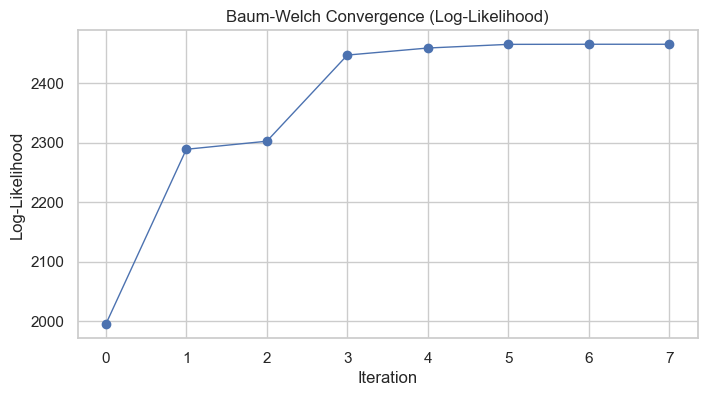

In [8]:
hmm = GaussianHMM(n_states=len(ACTIVITIES), n_features=len(feature_cols), random_state=RANDOM_SEED)
hmm.initialize_from_labeled(X_train_seq, y_train_seq)
ll_history = hmm.baum_welch(X_train_seq, max_iter=80, tol=1e-3, min_var=1e-3, verbose=True)

plt.figure(figsize=(8, 4))
plt.plot(ll_history, marker='o', linewidth=1)
plt.title('Baum-Welch Convergence (Log-Likelihood)')
plt.xlabel('Iteration')
plt.ylabel('Log-Likelihood')
plt.show()

In [9]:
def derive_state_label_map(hmm_model, X_seqs, y_seqs, n_states, n_labels):
    counts = np.zeros((n_states, n_labels), dtype=int)
    for X, y in zip(X_seqs, y_seqs):
        path = hmm_model.viterbi(X)
        for s, lbl in zip(path, y):
            counts[s, lbl] += 1

    state_to_label = {}
    used_labels = set()

    # Greedy one-to-one mapping from hidden states to activity labels
    for _ in range(min(n_states, n_labels)):
        best = None
        for s in range(n_states):
            if s in state_to_label:
                continue
            for l in range(n_labels):
                if l in used_labels:
                    continue
                val = counts[s, l]
                if best is None or val > best[0]:
                    best = (val, s, l)
        if best is None:
            break
        _, s_best, l_best = best
        state_to_label[s_best] = l_best
        used_labels.add(l_best)

    # Fill any leftover states with their row-wise majority label
    for s in range(n_states):
        if s not in state_to_label:
            state_to_label[s] = int(np.argmax(counts[s]))

    return state_to_label, counts

state_to_label, train_state_label_counts = derive_state_label_map(
    hmm, X_train_seq, y_train_seq, n_states=len(ACTIVITIES), n_labels=len(ACTIVITIES)
)

print('State to activity label map:')
for s in sorted(state_to_label):
    print(f'  State {s} -> {ID_TO_ACT[state_to_label[s]]}')

display(pd.DataFrame(train_state_label_counts, columns=ACTIVITIES))

State to activity label map:
  State 0 -> standing
  State 1 -> walking
  State 2 -> jump
  State 3 -> still


,standing,walking,jump,still
0,90,0,0,1
1,4,96,0,0
2,0,3,63,0
3,0,0,0,66


## 7. Evaluation on Unseen Files

In [10]:
def decode_with_map(hmm_model, X_seq, state_to_label_map):
    st = hmm_model.viterbi(X_seq)
    pred = np.array([state_to_label_map[s] for s in st], dtype=int)
    return st, pred

y_true_all = []
y_pred_all = []
state_paths_test = []

for X, y in zip(X_test_seq, y_test_seq):
    st, pred = decode_with_map(hmm, X, state_to_label)
    y_true_all.append(y)
    y_pred_all.append(pred)
    state_paths_test.append(st)

y_true = np.concatenate(y_true_all)
y_pred = np.concatenate(y_pred_all)

cm = confusion_matrix(y_true, y_pred, labels=list(range(len(ACTIVITIES))))
acc = accuracy_score(y_true, y_pred)

print(f'Overall test accuracy: {acc:.4f}')

rows = []
total = np.sum(cm)
for i, act in enumerate(ACTIVITIES):
    tp = cm[i, i]
    fn = np.sum(cm[i, :]) - tp
    fp = np.sum(cm[:, i]) - tp
    tn = total - tp - fn - fp

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    rows.append({
        'State (Activity)': act,
        'Number of Samples': int(np.sum(cm[i, :])),
        'Sensitivity': round(float(sensitivity), 4),
        'Specificity': round(float(specificity), 4),
        'Overall Accuracy': round(float(acc), 4),
    })

metrics_df = pd.DataFrame(rows)
display(metrics_df)

Overall test accuracy: 1.0000


,State (Activity),Number of Samples,Sensitivity,Specificity,Overall Accuracy
0,standing,19,1.0,1.0,1.0
1,walking,19,1.0,1.0,1.0
2,jump,11,1.0,1.0,1.0
3,still,12,1.0,1.0,1.0


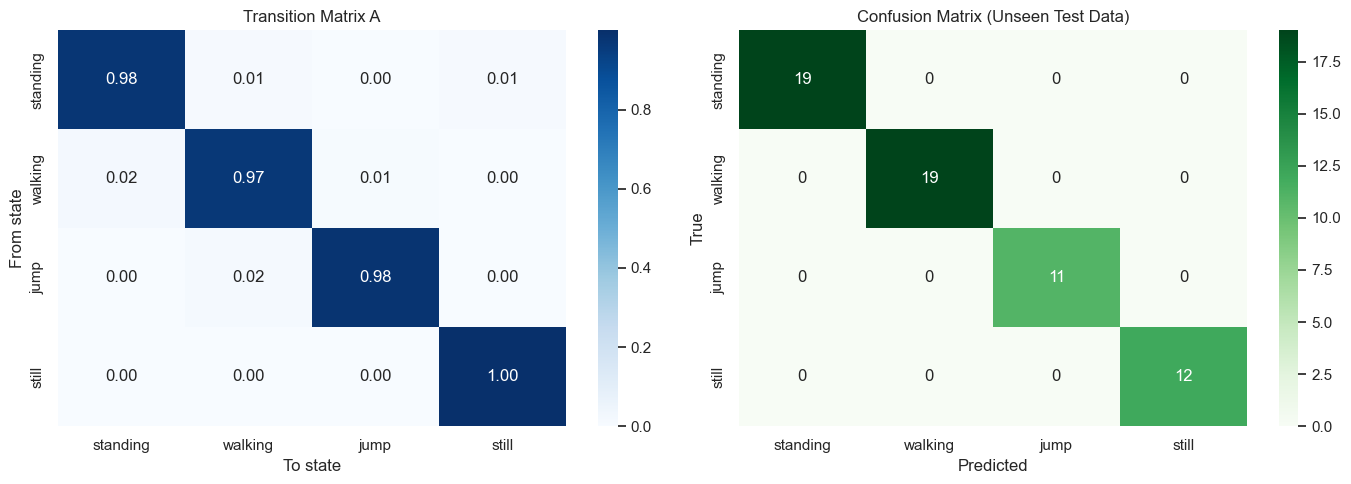

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(hmm.A, annot=True, fmt='.2f', cmap='Blues', xticklabels=ACTIVITIES, yticklabels=ACTIVITIES, ax=ax[0])
ax[0].set_title('Transition Matrix A')
ax[0].set_xlabel('To state')
ax[0].set_ylabel('From state')

cm_df = pd.DataFrame(cm, index=ACTIVITIES, columns=ACTIVITIES)
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Greens', ax=ax[1])
ax[1].set_title('Confusion Matrix (Unseen Test Data)')
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('True')

plt.tight_layout()
plt.show()

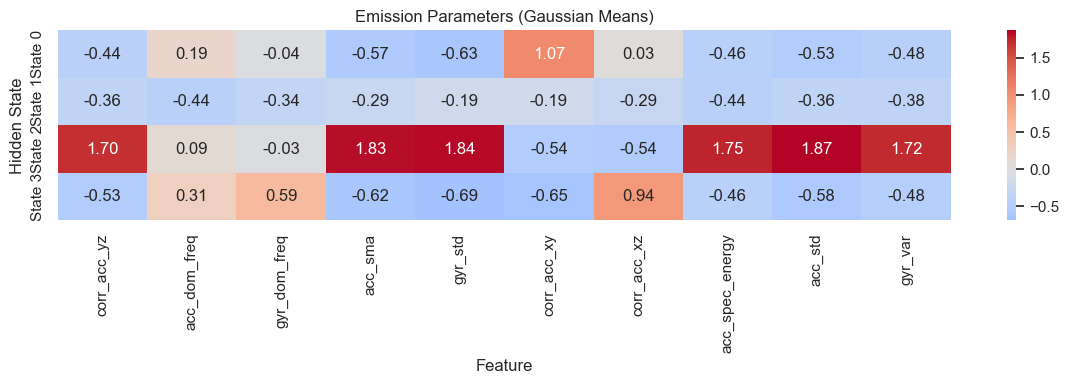

In [12]:
# Emission visualization: state-wise Gaussian means over top features by variance.
feature_var = np.var(np.vstack(X_train_seq), axis=0)
top_idx = np.argsort(feature_var)[-10:]
top_feats = [feature_cols[i] for i in top_idx]

means_top = hmm.means[:, top_idx]
means_df = pd.DataFrame(means_top, index=[f'State {i}' for i in range(len(ACTIVITIES))], columns=top_feats)

plt.figure(figsize=(12, 4))
sns.heatmap(means_df, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Emission Parameters (Gaussian Means)')
plt.xlabel('Feature')
plt.ylabel('Hidden State')
plt.tight_layout()
plt.show()

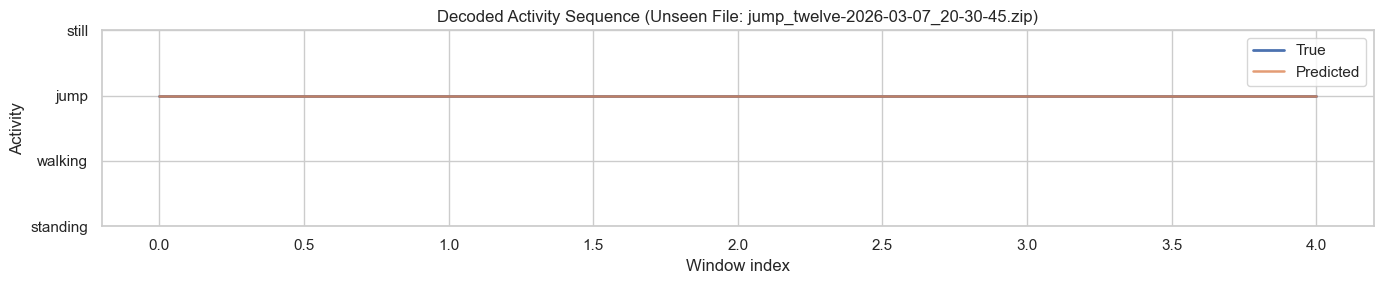

In [13]:
# Example decoded sequence for one unseen file
example_i = 0
true_seq = y_test_seq[example_i]
_, pred_seq = decode_with_map(hmm, X_test_seq[example_i], state_to_label)

plt.figure(figsize=(14, 3))
plt.plot(true_seq, label='True', linewidth=2)
plt.plot(pred_seq, label='Predicted', linewidth=1.8, alpha=0.8)
plt.yticks(list(range(len(ACTIVITIES))), ACTIVITIES)
plt.title(f'Decoded Activity Sequence (Unseen File: {test_files[example_i]})')
plt.xlabel('Window index')
plt.ylabel('Activity')
plt.legend()
plt.tight_layout()
plt.show()

## 8. Raw Data Visualization and Sampling-Rate Summary

acc_fs_raw                                    gyr_fs_raw            \
                mean       std         min         max        mean       std   
activity                                                                       
jump       99.668354  0.003087   99.662145   99.671085   99.668354  0.003087   
standing  100.188103  0.003373  100.181328  100.191366  100.188103  0.003373   
still      99.658516  0.003413   99.649235   99.661152   99.658516  0.003413   
walking   100.188972  0.006071  100.170289  100.192369  100.188972  0.006071   

                                 duration_s                          
                 min         max       mean       std    min    max  
activity                                                             
jump       99.662145   99.671085   7.618333  1.171680   5.96   9.32  
standing  100.181328  100.191366  11.008333  0.636951  10.60  12.92  
still      99.649235   99.661152   7.743077  1.403896   5.66  10.32  
walking   100.170289  100.192369  10.803077  0.101274  10.66  10.98

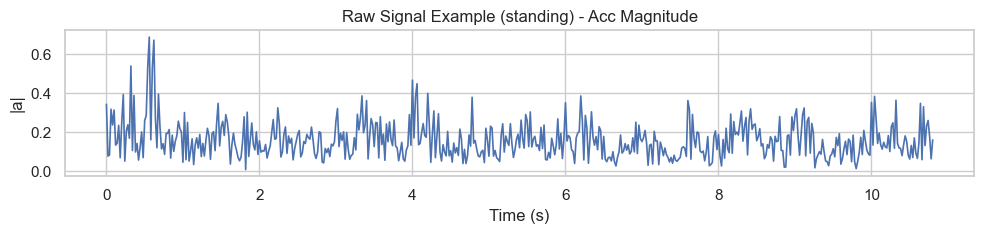

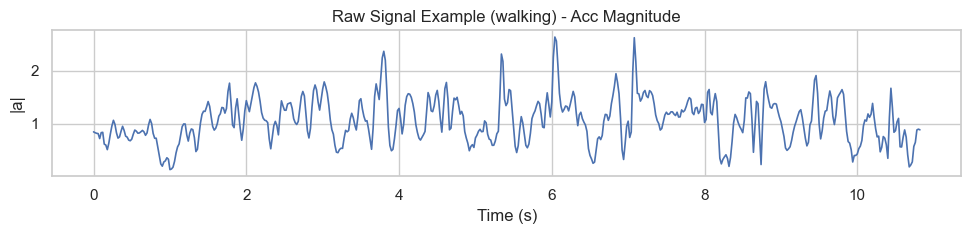

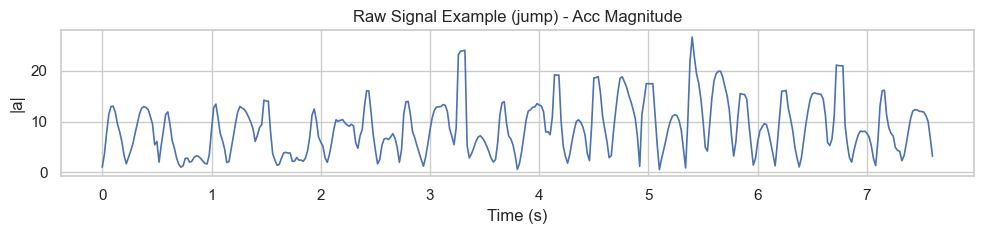

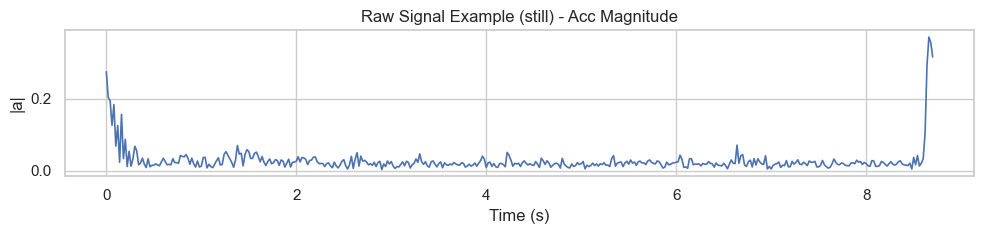

In [14]:
display(sampling_df.groupby('activity')[['acc_fs_raw', 'gyr_fs_raw', 'duration_s']].agg(['mean', 'std', 'min', 'max']))

for act in ACTIVITIES:
    ex_file = seq_df.loc[seq_df['activity'] == act, 'file'].iloc[0]
    ex_path = DATASET_DIR / ex_file
    merged, _, _ = load_and_harmonize(ex_path, TARGET_FS)
    amag = np.sqrt(merged['ax']**2 + merged['ay']**2 + merged['az']**2)

    plt.figure(figsize=(10, 2.5))
    plt.plot(merged['t'], amag, linewidth=1.2)
    plt.title(f'Raw Signal Example ({act}) - Acc Magnitude')
    plt.xlabel('Time (s)')
    plt.ylabel('|a|')
    plt.tight_layout()
    plt.show()

## 9. Task Allocation Table (For Report)

Use this table in your report to show collaboration and align with commit history.

| Team Member   | Assigned Activities | Main Technical Work | Evidence |
|---------------|---------------------|---------------------|----------|
| nshimiyeemmy  | Jumping, Still      | Data collection for jump/still sessions, notebook baseline implementation, feature pipeline, HMM training/evaluation setup | 4 dataset commits + notebook baseline commit |
| hirwaalu      | Standing, Walking   | Data collection for standing/walking sessions, report support section (task-allocation and submission-ready structure) | 4 dataset commits + notebook enhancement commit |

Balanced contribution target: 50/50 commit share and clearly separated activity ownership.